In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lake_ice_helpers import lake_files
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler,OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from count_analysis_helpers import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import time
from statsmodels.iolib.smpickle import save_pickle,load_pickle


In [ ]:
data_path = None #Add your path here
model_path = None
visualization_path = None
data_ip, ltbl_ice, ltbl_ice_depth, df_ice_clean = lake_files(data_path=data_path)

In [3]:
data_ip.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30871 entries, 1 to 37324
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   station_id          30871 non-null  object        
 1   year                30871 non-null  int64         
 2   ice_on              30871 non-null  datetime64[ns]
 3   ice_off             30871 non-null  datetime64[ns]
 4   ice_on_doy          30871 non-null  float64       
 5   ice_off_doy         30871 non-null  float64       
 6   ice_cover_duration  30871 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(1)
memory usage: 1.9+ MB


In [4]:
data_ip.ice_cover_duration.describe()

count    30871.000000
mean       164.737488
std         41.846904
min          0.000000
25%        142.000000
50%        169.000000
75%        193.000000
max        365.000000
Name: ice_cover_duration, dtype: float64

In [5]:
data_ip['year_normalized'] = (data_ip.year-data_ip.year.min())/(data_ip.year.max()-data_ip.year.min())
data_ip['ice_on_doy_normalized'] = (data_ip.ice_on_doy-data_ip.ice_on_doy.min())/(data_ip.ice_on_doy.max()-data_ip.ice_on_doy.min())

In [6]:
data_ip.describe()

,year,ice_on,ice_off,ice_on_doy,ice_off_doy,ice_cover_duration,year_normalized,ice_on_doy_normalized
count,30871.000000,30871,30871,30871.000000,30871.000000,30871.000000,30871.000000,30871.000000
mean,1978.891646,1978-10-16 00:45:56.762009696,1979-03-29 18:27:55.747465280,328.709987,128.221438,164.737488,0.390428,0.356831
min,1950.000000,1949-10-04 00:00:00,1950-01-09 00:00:00,242.000000,-61.000000,0.000000,0.000000,0.000000
25%,1965.000000,1964-10-26 00:00:00,1965-04-07 00:00:00,312.000000,117.000000,142.000000,0.202703,0.288066
50%,1977.000000,1976-11-25 00:00:00,1977-05-23 00:00:00,326.000000,131.000000,169.000000,0.364865,0.345679
75%,1991.000000,1990-11-12 00:00:00,1991-04-13 00:00:00,343.000000,143.000000,193.000000,0.554054,0.415638
max,2024.000000,2024-01-17 00:00:00,2024-07-12 00:00:00,485.000000,273.000000,365.000000,1.000000,1.000000
std,17.747641,NaN,NaN,24.634308,23.751834,41.846904,0.239833,0.101376


## Building models with intentional data leakages.
* Normalized covariates are used to avoid problems in model fitting. exp() -values can be huge with data such as years etc.
* Purpose is to check if Poisson-type distributions would make sense in modelling, we add ice_on_doy to model. 
* Fitting is done for full data and distributions seemed to work pretty well when modelling ice-duration.
* In these predictions all values are positive, but predictions can be above annual day counts 365/366.

In [7]:
#basic_model_equation = "ice_cover_duration~year_normalized+I(year_normalized**2)"
basic_model_equation = "ice_cover_duration~year_normalized+ice_on_doy_normalized"
y_basic,X_basic = dmatrices(basic_model_equation,
                            data_ip,
                            return_type="dataframe")

consul_model_basic = sm.GeneralizedPoisson(y_basic,
                                            X_basic,
                                            p=1).fit(maxiter=10**7)
consul_model_basic_preds = consul_model_basic.predict(X_basic)
print(consul_model_basic.summary())


Optimization terminated successfully.
         Current function value: 4.662776
         Iterations: 13
         Function evaluations: 15
         Gradient evaluations: 15
                    GeneralizedPoisson Regression Results                     
Dep. Variable:     ice_cover_duration   No. Observations:                30871
Model:             GeneralizedPoisson   Df Residuals:                    30868
Method:                           MLE   Df Model:                            2
Date:                Sat, 05 Apr 2025   Pseudo R-squ.:                  0.1293
Time:                        21:15:10   Log-Likelihood:            -1.4394e+05
converged:                       True   LL-Null:                   -1.6532e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept       

## Saving and loading model
You can skip model fitting and import the pretrained model with command 

load_pickle('leaky_consul_model_basic.pickle')

as shown below:

In [9]:
#from statsmodels.iolib.smpickle import save_pickle,load_pickle

#save_pickle(consul_model_basic,model_path+'\\leaky_consul_model_basic.pickle')

In [10]:
#cm = load_pickle(model_path+'\\leaky_consul_model_basic.pickle')

In [11]:
#cm.predict(X_basic)

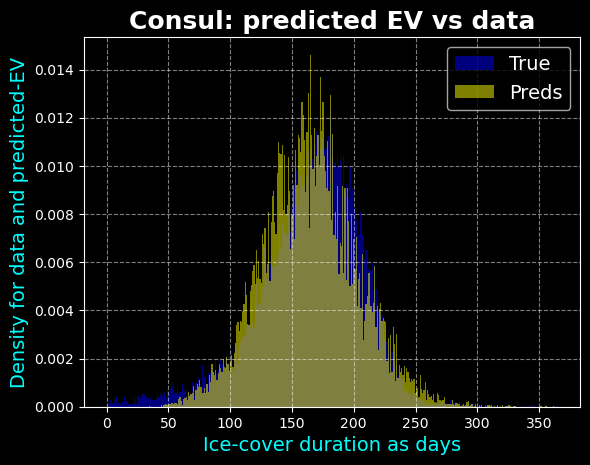

In [8]:
preds_vs_true_distribution(model_preds=consul_model_basic_preds,
                                true=data_ip.ice_cover_duration,
                                titles={'title':'Consul: predicted EV vs data',
                                   'xlabel':'Ice-cover duration as days',
                                   'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'white',
                                    'preds':'yellow',
                                    'true':'blue',
                                    'xlabel':'cyan',
                                    'ylabel':'cyan'},
                                #return_fig=True,
                                #file_path=visualization_path+'leaky_Consul_duration_EV_preds_vs_data.png',
                                #file_path=None
                           )


In [9]:
mean_squared_error(consul_model_basic_preds,data_ip.ice_cover_duration)

457.903615543472

MSE and 95 % confidence interval:

In [10]:
#from lake_ice_helpers import short_mse_analysis
consul_mse_dict = short_mse_analysis(consul_model_basic_preds,y_basic,return_variables=True)

MSE: 457.903615543472
Squared error std scaled: 7.025863638852827
95% lower bound: 444.13292281132044
95% upper bound: 471.6743082756235


In [11]:
consul_mse_dict

{'mse': 457.903615543472,
 'SE_of_mse': 7.025863638852827,
 'squared_errors': 1         359.496286
 2        1066.638749
 3        3923.567399
 4         225.366239
 5        3051.333595
             ...     
 37320    2527.873207
 37321     856.489483
 37322     628.783128
 37323    1361.167132
 37324    2302.347959
 Length: 30871, dtype: float64,
 '95%_lower': 444.13292281132044,
 '95%_upper': 471.6743082756235}

In [12]:
X_basic.head()

,Intercept,year_normalized,ice_on_doy_normalized
1,1.0,0.013514,0.259259
2,1.0,0.027027,0.234568
3,1.0,0.040541,0.164609
4,1.0,0.054054,0.296296
5,1.0,0.081081,0.148148


In [20]:
#from count_analysis_helpers import get_annual_count_distribution,get_dataset_count_distribution

In [13]:
test_year_model,test_year_frame = get_annual_count_distribution(consul_model_basic,X_basic.iloc[0,:])

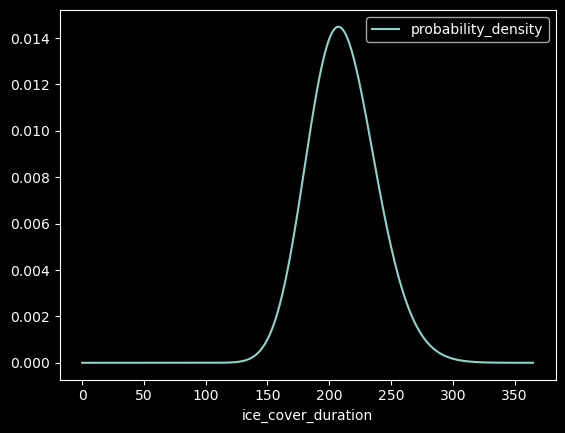

In [14]:
test_year_frame.plot();

In [18]:
consul_model_distribution,consul_model_prob_matrix,consul_model_density = get_dataset_count_distribution(consul_model_basic,X_basic,return_probs=True)

In [19]:
X_basic.shape,consul_model_prob_matrix.sum(axis=1).sum()

((30871, 3), 30871.0)

In [20]:
consul_model_density.head()

,probability_density
ice_cover_duration,
0,5.305210e-13
1,5.951940e-12
2,3.523584e-11
3,1.465524e-10
4,4.811693e-10


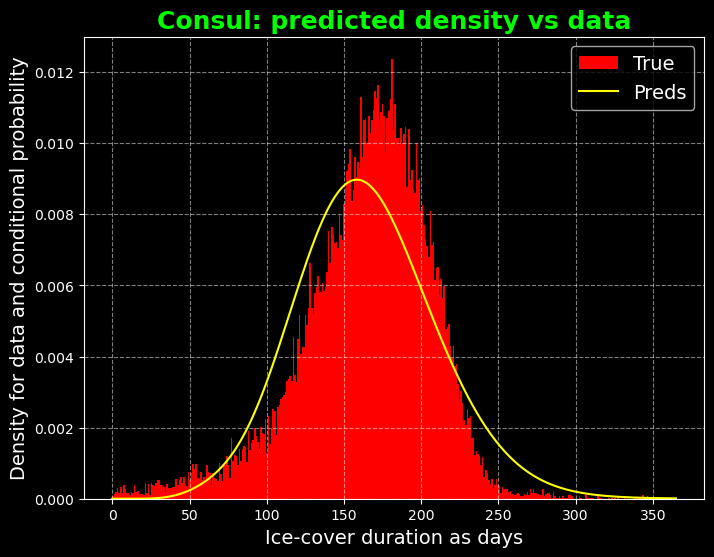

In [ ]:
colors = {'preds':'yellow','true':'red','title':'lime','xlabel':'white','ylabel':'white'}
titles = {'title':'Consul: predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=consul_model_density,
                    true_observations=data_ip.ice_cover_duration,
                    colors=colors,
                    titles=titles,
                    #return_fig=True,
                    #file_path=visualization_path+'leaky_Consul_duration_cumulated_density_vs_data.png'
                    )

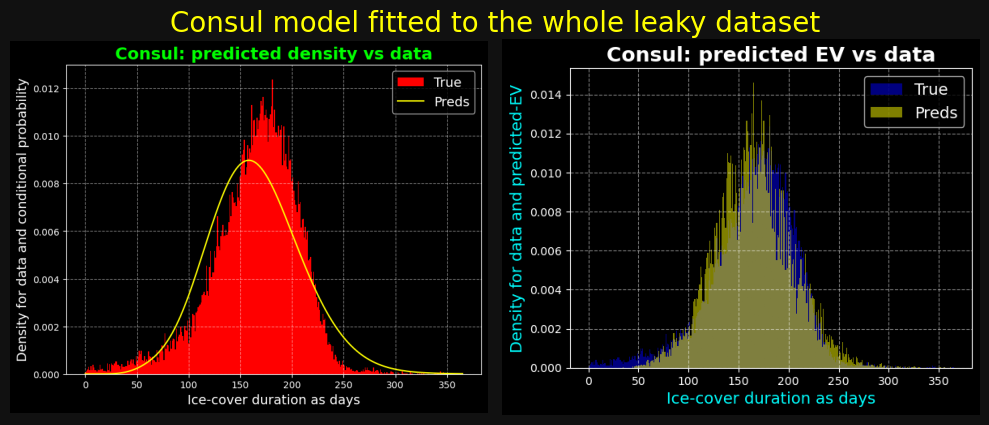

In [ ]:
density_path = visualization_path+'leaky_Consul_duration_cumulated_density_vs_data.png'
ev_path = visualization_path+'leaky_Consul_duration_EV_preds_vs_data.png'

combine_plot_images(density_path=density_path,
                    ev_path=ev_path,
                    title='Consul model fitted to the whole leaky dataset',
                    #file_path=visualization_path+'leaky_Consul_combined_distribution_visualization.png',
                    )

## Same analysis with Generalized Poisson model of Felix Famoyes:

In [25]:
famoyes_model_basic = sm.GeneralizedPoisson(y_basic,
                                            X_basic,
                                            p=2).fit(maxiter=10**7)
famoyes_model_basic_preds = famoyes_model_basic.predict(X_basic)
print(famoyes_model_basic.summary())


Optimization terminated successfully.
         Current function value: 4.751965
         Iterations: 11
         Function evaluations: 19
         Gradient evaluations: 19
                    GeneralizedPoisson Regression Results                     
Dep. Variable:     ice_cover_duration   No. Observations:                30871
Model:             GeneralizedPoisson   Df Residuals:                    30868
Method:                           MLE   Df Model:                            2
Date:                Sat, 05 Apr 2025   Pseudo R-squ.:                  0.1126
Time:                        21:18:30   Log-Likelihood:            -1.4670e+05
converged:                       True   LL-Null:                   -1.6532e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept       

In [31]:
# from statsmodels.iolib.smpickle import save_pickle,load_pickle

# save_pickle(famoyes_model_basic,model_path+'\\leaky_famoyes_model_basic.pickle')

In [32]:
#fm = load_pickle(model_path+'\\leaky_famoyes_model_basic.pickle')

In [33]:
#fm.predict(X_basic)

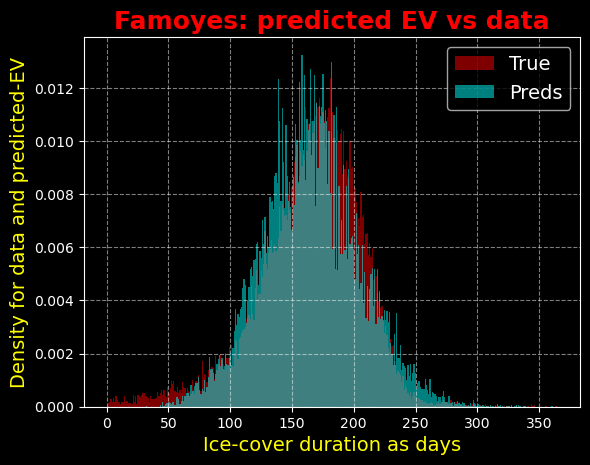

In [26]:
preds_vs_true_distribution(model_preds=famoyes_model_basic_preds,
                                true=data_ip.ice_cover_duration,
                                titles={'title':'Famoyes: predicted EV vs data',
                                   'xlabel':'Ice-cover duration as days',
                                   'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'red',
                                    'preds':'cyan',
                                    'true':'red',
                                    'xlabel':'yellow',
                                    'ylabel':'yellow'},
                                #file_path=visualization_path+'leaky_Famoyes_duration_EV_preds_vs_data.png',
                                #file_path=None
                           )

In [27]:
mean_squared_error(famoyes_model_basic_preds,data_ip.ice_cover_duration)

467.8038422065958

In [28]:
famoyes_mse_dict = short_mse_analysis(famoyes_model_basic_preds,y_basic,return_variables=True)

MSE: 467.8038422065958
Squared error std scaled: 7.075100102249403
95% lower bound: 453.93664600618695
95% upper bound: 481.67103840700463


In [29]:
famoyes_model_distribution,famoyes_model_prob_matrix,famoyes_model_density = get_dataset_count_distribution(famoyes_model_basic,X_basic,return_probs=True)

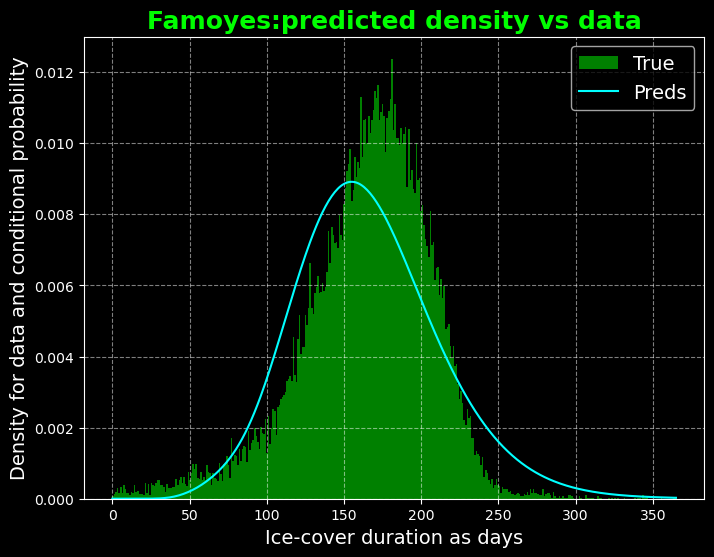

In [ ]:
colors = {'preds':'cyan','true':'green','title':'lime','xlabel':'white','ylabel':'white'}
titles = {'title':'Famoyes:predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=famoyes_model_density,
                    true_observations=data_ip.ice_cover_duration,
                    colors=colors,
                    titles=titles,
                    #return_fig=True,
                    #file_path=visualization_path+'leaky_Famoyes_duration_cumulated_density_vs_data.png'
                    )

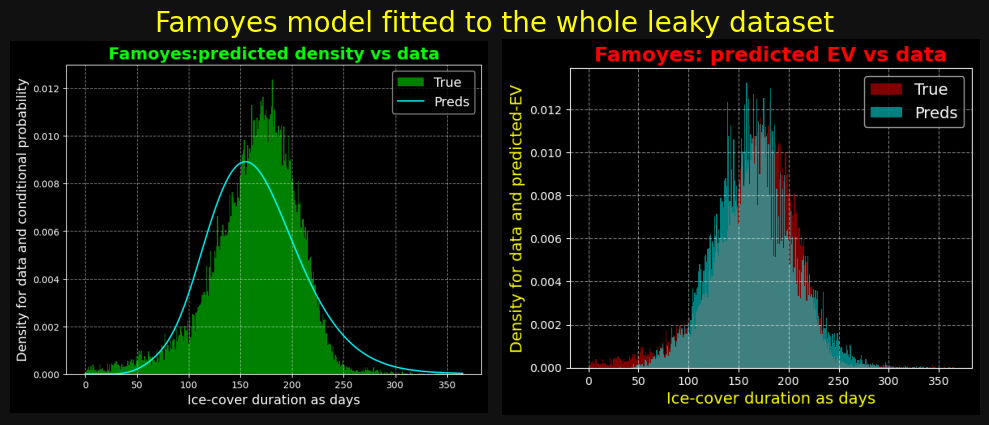

In [ ]:
density_path_famoyes = visualization_path+'leaky_Famoyes_duration_cumulated_density_vs_data.png'
ev_path_famoyes = visualization_path+'leaky_Famoyes_duration_EV_preds_vs_data.png'

combine_plot_images(density_path=density_path_famoyes,
                    ev_path=ev_path_famoyes,
                    title='Famoyes model fitted to the whole leaky dataset',
                    #file_path=visualization_path+'leaky_Famoyes_combined_distribution_visualization.png',
                    )

Then analysis with standard Poisson regression model:

In [34]:
poisson_model_basic = sm.GLM(y_basic,X_basic,family=sm.families.Poisson()).fit(maxiter=10000)
poisson_model_basic_preds = poisson_model_basic.predict(X_basic)

print(poisson_model_basic.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:     ice_cover_duration   No. Observations:                30871
Model:                            GLM   Df Residuals:                    30868
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.6103e+05
Date:                Sat, 05 Apr 2025   Deviance:                   1.0921e+05
Time:                        21:19:57   Pearson chi2:                 9.59e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9998
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.95

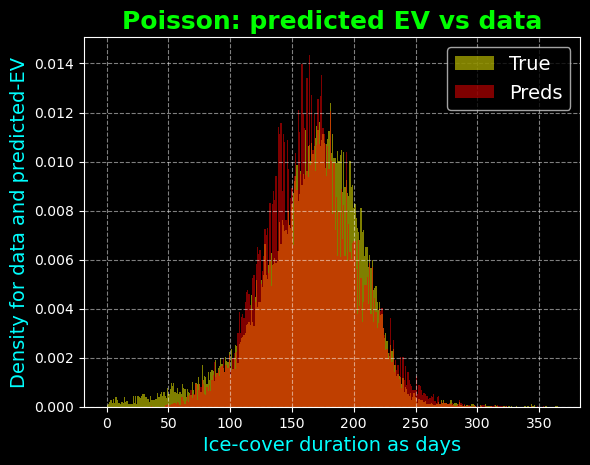

In [35]:
preds_vs_true_distribution(model_preds=poisson_model_basic_preds,
                                true=data_ip.ice_cover_duration,
                                titles={'title':'Poisson: predicted EV vs data',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'lime',
                                        'xlabel':'cyan',
                                        'ylabel':'cyan',
                                        'preds':'red',
                                        'true':'yellow'},
                                #file_path=visualization_path+'leaky_Poisson_duration_EV_preds_vs_data.png',
                                #file_path=None
                                )

In [42]:
#from statsmodels.iolib.smpickle import save_pickle,load_pickle

#save_pickle(poisson_model_basic,model_path+'\\leaky_poisson_model_basic.pickle')


In [43]:
#ps = load_pickle(model_path+'\\leaky_poisson_model_basic.pickle')

In [44]:
#print(ps.summary())

In [36]:
mean_squared_error(poisson_model_basic_preds,data_ip.ice_cover_duration)

450.7958463545311

In [37]:
poisson_model_distribution,poisson_model_prob_matrix,poisson_model_pseudo_density = get_dataset_count_distribution(poisson_model_basic,X_basic,return_probs=True)

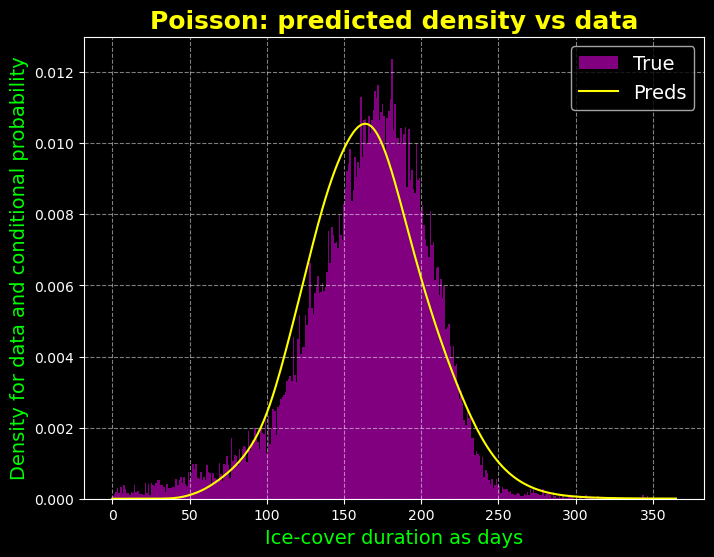

In [ ]:
colors_poisson = {'preds':'yellow','true':'purple','title':'yellow','xlabel':'lime','ylabel':'lime'}
titles_poisson = {'title':'Poisson: predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=poisson_model_pseudo_density,
                    true_observations=data_ip.ice_cover_duration,
                    colors=colors_poisson,
                    titles=titles_poisson,
                    #return_fig=True,
                    #file_path=visualization_path+'leaky_Poisson_duration_cumulated_density_vs_data.png'
                    )

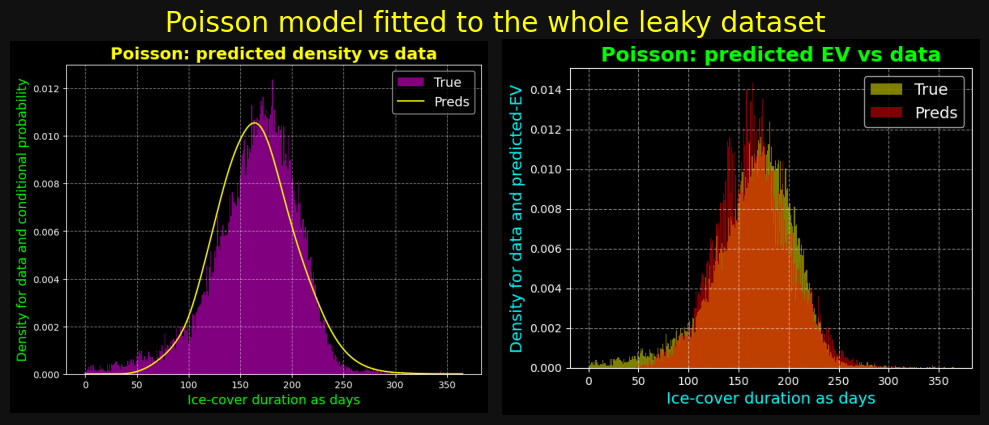

In [ ]:
density_path_poisson = visualization_path+'leaky_Poisson_duration_cumulated_density_vs_data.png'
ev_path_poisson = visualization_path+'leaky_Poisson_duration_EV_preds_vs_data.png'

combine_plot_images(density_path=density_path_poisson,
                    ev_path=ev_path_poisson,
                    title='Poisson model fitted to the whole leaky dataset',
                    #file_path=visualization_path+'leaky_Poisson_combined_distribution_visualization.png',
                    )

## Next few steps are redundant sanity checking for distributions:

In [42]:
poisson_model_basic_distribution = poisson_model_basic.get_distribution(X_basic) # This is so called scipy.stats frozen distribution.

Sanity checking the expectations:

In [43]:
poisson_probs = np.zeros((X_basic.shape[0],601))
for i in range(601):
    poisson_probs[:,i] = poisson_model_basic_distribution.pmf(i) # Collecting point mass for 'day counts' between 0 and 600.

In [44]:
poisson_preds_sanity_check = poisson_probs@np.arange(0,601) # This matrix multiplication gives expected value for each ice-cover duration, based on this model.

All values are not exactly the same. Some observations are getting extreme predictions. But quite close, as we can see:

In [45]:
np.allclose(poisson_model_basic_preds,poisson_preds_sanity_check)

True

In [46]:
short_mse_analysis(poisson_model_basic_distribution.ppf(0.5),y_basic)

MSE: 450.82984030319716
Squared error std scaled: 7.0674448306603495
95% lower bound: 436.9776484351029
95% upper bound: 464.68203217129144


In [47]:
poisson_mse_dict = short_mse_analysis(poisson_model_basic_preds,y_basic,return_variables=True)

MSE: 450.7958463545311
Squared error std scaled: 7.0823988614732505
95% lower bound: 436.9143445860435
95% upper bound: 464.67734812301865


In [48]:
print('Consul:',consul_model_basic_preds.describe(),sep='\n')
print()
print('Famoyes:',famoyes_model_basic_preds.describe(),sep='\n')
print()
print('Poisson:',poisson_model_basic_preds.describe(),sep='\n')
print()
print('Data:',data_ip.ice_cover_duration.describe(),sep='\n')

Consul:
count    30871.000000
mean       164.737490
std         38.381879
min         34.300938
25%        139.301847
50%        164.361655
75%        189.026029
max        385.569629
dtype: float64

Famoyes:
count    30871.000000
mean       165.198461
std         39.616152
min         32.678659
25%        138.813264
50%        164.546088
75%        190.228903
max        396.397100
dtype: float64

Poisson:
count    30871.000000
mean       164.737488
std         37.152165
min         36.044639
25%        140.111318
50%        164.422342
75%        188.415851
max        375.009779
dtype: float64

Data:
count    30871.000000
mean       164.737488
std         41.846904
min          0.000000
25%        142.000000
50%        169.000000
75%        193.000000
max        365.000000
Name: ice_cover_duration, dtype: float64


## Short analysis for cleaned ice data:

In [49]:
df_ice_clean['log_area_ha'] = np.log(df_ice_clean['area_ha'])

In [50]:
df_ice_clean.describe()

,year,ice_on,ice_off,ice_on_doy,ice_off_doy,ice_cover_duration,lake_id,lat_wgs84,lon_wgs84,altitude_m,area_ha,depth_max_m,log_area_ha
count,22279.000000,22279,22279,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,22279.000000,2.227900e+04,22279.000000,22279.000000
mean,1979.173212,1979-01-31 10:45:07.231024736,1979-07-08 00:58:45.185151872,333.279591,125.650568,157.592800,506.018223,60.837106,5.434057,231.508377,2.444760e+04,42.366638,7.498276
min,1950.000000,1949-10-04 00:00:00,1950-01-09 00:00:00,242.000000,-61.000000,0.000000,2.000000,42.417400,-154.321000,0.900000,6.000000e-01,1.000000,-0.510826
25%,1964.000000,1963-12-14 12:00:00,1964-05-20 00:00:00,317.000000,115.000000,136.000000,296.000000,59.220235,13.555768,92.000000,5.005100e+02,16.000000,6.215628
50%,1977.000000,1976-12-11 00:00:00,1977-05-23 00:00:00,330.000000,128.000000,163.000000,530.000000,61.658505,15.518629,170.700000,1.594470e+03,28.000000,7.374297
75%,1991.000000,1991-01-14 00:00:00,1991-05-29 00:00:00,346.000000,140.000000,185.000000,684.000000,63.691504,19.819981,342.600000,5.624110e+03,57.120000,8.634818
max,2024.000000,2024-01-17 00:00:00,2024-07-12 00:00:00,485.000000,250.000000,356.000000,1197.000000,82.485328,30.414821,1522.000000,3.115300e+06,614.000000,14.951836
std,18.214245,NaN,NaN,23.982839,23.893666,40.883277,279.281465,4.897502,37.021040,180.448003,1.722365e+05,49.734784,2.100511


In [51]:
df_ice_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22279 entries, 0 to 22278
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   station_id          22279 non-null  object        
 1   year                22279 non-null  int64         
 2   ice_on              22279 non-null  datetime64[ns]
 3   ice_off             22279 non-null  datetime64[ns]
 4   ice_on_doy          22279 non-null  float64       
 5   ice_off_doy         22279 non-null  float64       
 6   ice_cover_duration  22279 non-null  float64       
 7   lake_id             22279 non-null  int64         
 8   country             22279 non-null  object        
 9   lake_name           22279 non-null  object        
 10  lat_wgs84           22279 non-null  float64       
 11  lon_wgs84           22279 non-null  float64       
 12  altitude_m          22279 non-null  float64       
 13  area_ha             22279 non-null  float64   

## Indicator features for country and transformations for data
* We begin with creating the indicator columns for country values.
* Then transformations for data and test-modelling.
* Choosing log-area decreases MSE a bit, but did not create statistically significant improvement with standard scaling.

In [52]:
country_encoder = OneHotEncoder(sparse_output=False).fit(df_ice_clean[['country']])

In [53]:
df_nums = pd.DataFrame(country_encoder.transform(df_ice_clean[['country']]),columns=country_encoder.categories_)
#num_cols = ['lat_wgs84','lon_wgs84','altitude_m','area_ha','depth_max_m']
num_cols = ['lat_wgs84','lon_wgs84','altitude_m','log_area_ha','depth_max_m']
df_nums[num_cols] = df_ice_clean[num_cols].copy().values

In [54]:
np.allclose(df_nums[num_cols],df_ice_clean[num_cols])

True

Checking how well transformation to theoretically standard normal distribution works in practice:

In [55]:
((df_nums - df_nums.mean(axis=0))/df_nums.std(axis=0)).describe()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m
count,2.227900e+04,2.227900e+04,22279.000000,2.227900e+04,2.227900e+04,2.227900e+04,2.227900e+04,2.227900e+04,2.227900e+04,2.227900e+04
mean,4.082296e-17,-1.632918e-16,0.000000,8.164592e-17,-4.082296e-17,-4.082296e-17,-4.082296e-17,-1.122631e-16,-5.613157e-16,-1.020574e-17
std,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.990546e-01,-5.703748e-01,-0.220161,-1.224443e+00,-1.643536e-01,-3.761041e+00,-4.315250e+00,-1.277977e+00,-3.812931e+00,-8.317446e-01
25%,-2.990546e-01,-5.703748e-01,-0.220161,-1.224443e+00,-1.643536e-01,-3.301420e-01,2.193810e-01,-7.731223e-01,-6.106364e-01,-5.301448e-01
50%,-2.990546e-01,-5.703748e-01,-0.220161,8.166615e-01,-1.643536e-01,1.677180e-01,2.724011e-01,-3.369856e-01,-5.902332e-02,-2.888650e-01
75%,-2.990546e-01,-5.703748e-01,-0.220161,8.166615e-01,-1.643536e-01,5.828274e-01,3.885878e-01,6.156434e-01,5.410790e-01,2.966407e-01
max,3.343721e+00,1.753154e+00,4.541935,8.166615e-01,6.084169e+00,4.420258e+00,6.747721e-01,7.151598e+00,3.548451e+00,1.149363e+01


## Scaling data to similar range
* Different scaling gives different results for covariate analysis.
* MSE is a bit lower with MinMax-scaling as a number, but not even close of being significantly lower.
* With standard scaling, the country indicator coefficients and standard deviation results are looking absurd.
* Models clearly have trouble to weight the effect of country indicators. Other variables are more stable to model.


In [56]:
#df_nums = pd.DataFrame(data=MinMaxScaler().fit_transform(df_nums),
#                       columns=df_nums.columns) # Scaling to MinMax
df_nums = (df_nums - df_nums.mean(axis=0))/df_nums.std(axis=0) # Standard scaling
df_nums

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m
0,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878
1,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878
2,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878
3,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878
4,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878
...,...,...,...,...,...,...,...,...,...,...
22274,-0.299055,-0.570375,-0.220161,-1.224443,6.084169,-3.631260,-2.562301,0.152352,-1.230249,-0.767403
22275,-0.299055,-0.570375,-0.220161,-1.224443,6.084169,-3.631260,-2.562301,0.152352,-1.230249,-0.767403
22276,-0.299055,-0.570375,-0.220161,-1.224443,6.084169,-3.631260,-2.562301,0.152352,-1.230249,-0.767403
22277,-0.299055,-0.570375,-0.220161,-1.224443,6.084169,-3.631260,-2.562301,0.152352,-1.230249,-0.767403


In [57]:
df_ice_cover_duration = df_nums.copy()
df_ice_cover_duration['ice_cover_duration'] = df_ice_clean['ice_cover_duration'].copy()
df_ice_cover_duration.head()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,ice_cover_duration
0,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,168.0
1,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,190.0
2,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,207.0
3,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,183.0
4,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,209.0


In [58]:
np.unique(df_ice_cover_duration.CA,return_counts=True)

(array([-0.29905457,  3.34372118]), array([20450,  1829], dtype=int64))

In [59]:
create_model_equation(df_ice_cover_duration.columns.values[:-1],df_ice_cover_duration.columns.values[-1][0])

'ice_cover_duration~CA+FI+NO+SE+US+lat_wgs84+lon_wgs84+altitude_m+log_area_ha+depth_max_m'

In [60]:
mv_lin_Poisson_eq = create_model_equation(df_ice_cover_duration.columns.values[:-1],df_ice_cover_duration.columns.values[-1][0])
y_mv,X_mv = dmatrices(mv_lin_Poisson_eq,
                            df_ice_cover_duration,
                            return_type="dataframe")

mv_lin_poisson_model = sm.GLM(y_mv,X_mv,family=sm.families.Poisson()).fit(maxiter=10000)
mv_lin_poisson_model_preds = mv_lin_poisson_model.predict(X_mv)

print(mv_lin_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     ice_cover_duration   No. Observations:                22279
Model:                            GLM   Df Residuals:                    22269
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4310e+05
Date:                Sat, 05 Apr 2025   Deviance:                   1.3368e+05
Time:                        21:24:12   Pearson chi2:                 1.15e+05
No. Iterations:                 10000   Pseudo R-squ. (CS):             0.9981
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0401      0.001   8904.015      

In [69]:
## Saving model to pickel file
#save_pickle(mv_lin_poisson_model,model_path+'\\lake_data_poisson_model_standardized_data_log_area.pickle')


In [61]:
## Opening model from pickle file and printing the results
ps_lake = load_pickle(model_path+'\\lake_data_poisson_model_minmax_data.pickle')
print(ps_lake.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     ice_cover_duration   No. Observations:                22279
Model:                            GLM   Df Residuals:                    22269
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4003e+05
Date:                Sat, 05 Apr 2025   Deviance:                   1.2752e+05
Time:                        21:24:34   Pearson chi2:                 1.09e+05
No. Iterations:                 10000   Pseudo R-squ. (CS):             0.9985
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.7958      0.009    301.652      

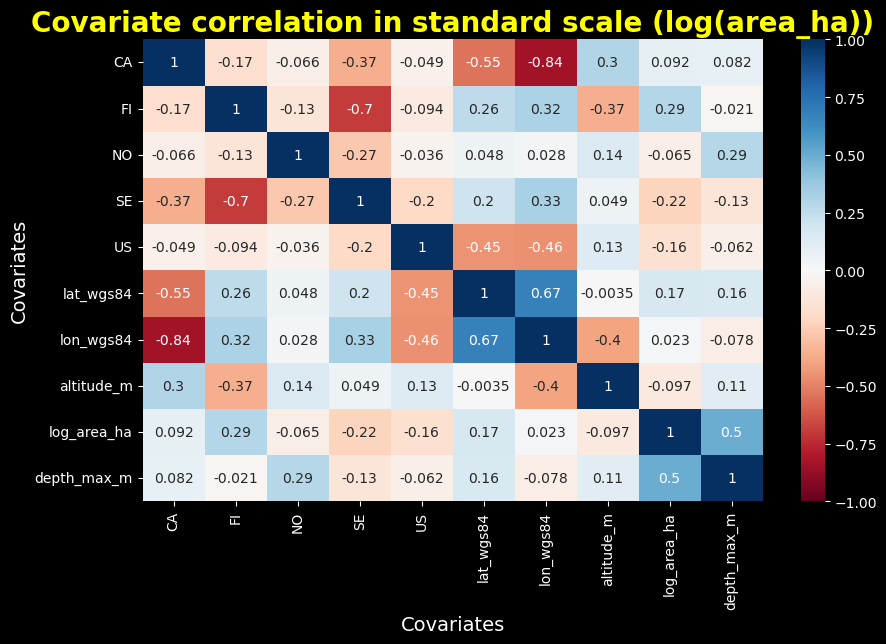

In [62]:
plt.figure(figsize=(10,6))
correlation_heatmap = sns.heatmap(df_nums.corr(),
                                  vmin=-1,
                                  vmax=1,
                                  annot=True,
                                  cmap='RdBu'
                                  )

plt.xlabel('Covariates',fontsize=14)
plt.ylabel('Covariates',fontsize=14)

plt.title('Covariate correlation in standard scale (log(area_ha))',
        fontsize=20,
        color='yellow',
        fontweight='bold')
#plt.savefig(visualization_path+'corr_in_snd_log_area.png',
#            bbox_inches='tight')
plt.show()

In [63]:
mean_squared_error(mv_lin_poisson_model_preds,y_mv)

767.0027226668808

In [64]:
len(mv_lin_poisson_model_preds),len(y_mv)

(22279, 22279)

Short analysis for the theoretical distribution of MSE:

In [65]:
mv_lin_poisson_mse_dict = short_mse_analysis(mv_lin_poisson_model_preds,y_mv,return_variables=True)

MSE: 767.0027226668808
Squared error std scaled: 22.455381014554277
95% lower bound: 722.9901758783544
95% upper bound: 811.0152694554072


In [75]:
#print(mv_lin_poisson_mse_dict)

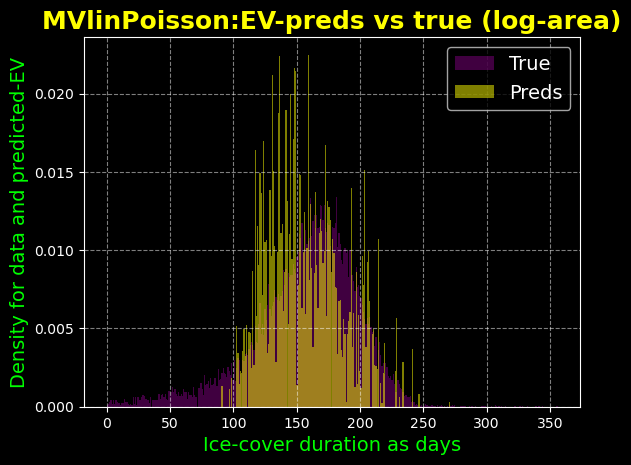

In [66]:
preds_vs_true_distribution(model_preds=mv_lin_poisson_model_preds,
                                #true=pd.DataFrame(y_mv.values.reshape(len(y_mv)),columns=['ice_cover_duration']),
                                true=pd.Series(y_mv.values.reshape(len(y_mv))),
                                titles={'title':'MVlinPoisson:EV-preds vs true (log-area)',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'yellow',
                                        'xlabel':'lime',
                                        'ylabel':'lime',
                                        'preds':'yellow',
                                        'true':'purple'},
                                #file_path=visualization_path+'mv_linear_Poisson_EV_preds_vs_true_log_area.png',
                                #file_path=None
                                )

In [67]:
mvlinpoisson_model_distribution,mvlinpoisson_model_prob_matrix,mvlinpoisson_model_density = get_dataset_count_distribution(mv_lin_poisson_model,X_mv,return_probs=True)

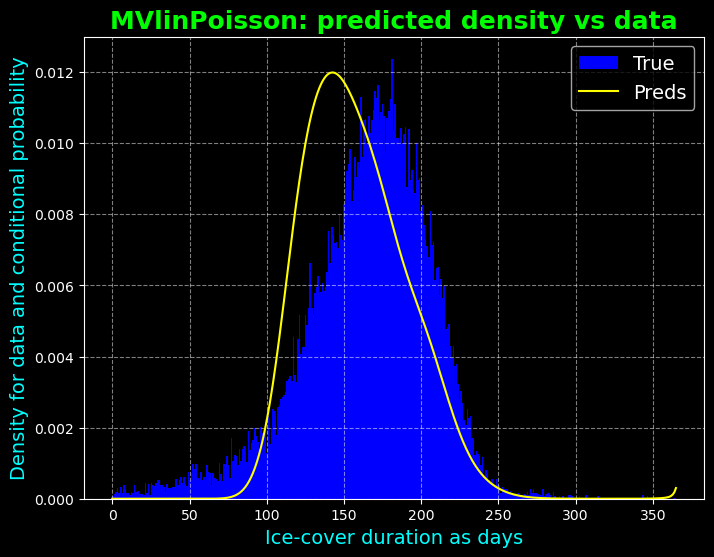

In [ ]:
colors_mvlinpoisson = {'preds':'yellow','true':'blue','title':'lime','xlabel':'cyan','ylabel':'cyan'}
titles_mvlinpoisson = {'title':'MVlinPoisson: predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=mvlinpoisson_model_density,
                    true_observations=data_ip.ice_cover_duration,
                    colors=colors_mvlinpoisson,
                    titles=titles_mvlinpoisson,
                    #return_fig=True,
                    #file_path=visualization_path+'mv_linear_Poisson_duration_cumulated_density_vs_data_log_area.png'
                    )

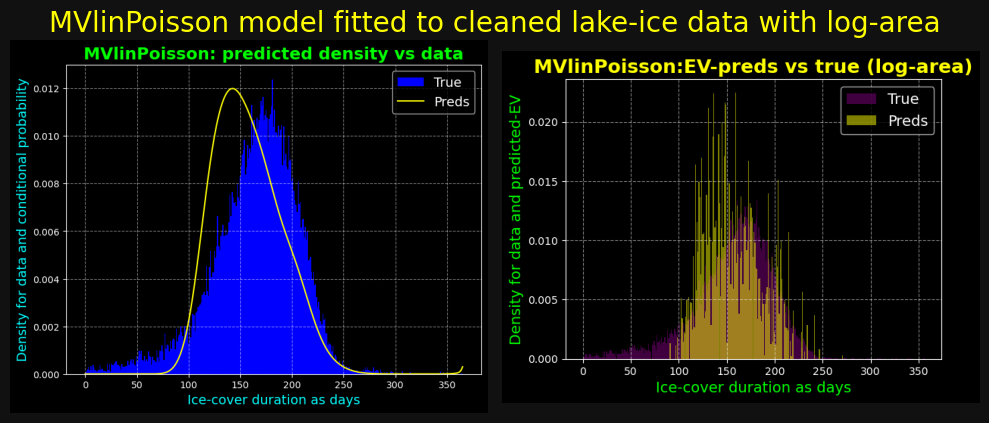

In [ ]:
density_path_mvlinpoisson = visualization_path+'mv_linear_Poisson_duration_cumulated_density_vs_data_log_area.png'
ev_path_mvlinpoisson = visualization_path+'mv_linear_Poisson_EV_preds_vs_true_log_area.png'

combine_plot_images(density_path=density_path_mvlinpoisson,
                    ev_path=ev_path_mvlinpoisson,
                    title='MVlinPoisson model fitted to cleaned lake-ice data with log-area',
                    #file_path=visualization_path+'mv_linear_Poisson_combined_distribution_visualization.png',
                    )

* Distribution is too much weighted towards smaller durations.
* Still, occasionally this model gives some way too large predictions. Annual day counts are not capped to 365.
* Yet again, a neural network model could solve this problem.

In [72]:
mv_lin_poisson_model_preds.describe()

count    22279.000000
mean       157.482701
std         32.572764
min         91.134527
25%        134.331870
50%        153.448098
75%        176.736466
max        758.142088
dtype: float64

In [73]:
mv_lin_poisson_model_preds.isna().any()

False

## Polynomial-Poisson regression

In [74]:
poly = PolynomialFeatures(degree=2,include_bias=False)
df_poly = pd.DataFrame(poly.fit_transform(df_ice_cover_duration.iloc[:,:-1]),
                       columns=poly.get_feature_names_out([x[0] for x in df_ice_cover_duration.columns][:-1]))
df_poly['ice_cover_duration'] = df_ice_cover_duration['ice_cover_duration'].copy()

In [75]:
df_poly.head()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,...,lon_wgs84 altitude_m,lon_wgs84 log_area_ha,lon_wgs84 depth_max_m,altitude_m^2,altitude_m log_area_ha,altitude_m depth_max_m,log_area_ha^2,log_area_ha depth_max_m,depth_max_m^2,ice_cover_duration
0,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,168.0
1,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,190.0
2,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,207.0
3,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,183.0
4,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,209.0


In [77]:
df_poly.columns = columns_for_model_equation(df_poly.columns)
df_poly.head()

,CA,FI,NO,SE,US,lat_wgs84,lon_wgs84,altitude_m,log_area_ha,depth_max_m,...,lon_wgs84_x_altitude_m,lon_wgs84_x_log_area_ha,lon_wgs84_x_depth_max_m,altitude_m_2nd,altitude_m_x_log_area_ha,altitude_m_x_depth_max_m,log_area_ha_2nd,log_area_ha_x_depth_max_m,depth_max_m_2nd,ice_cover_duration
0,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,168.0
1,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,190.0
2,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,207.0
3,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,183.0
4,-0.299055,-0.570375,-0.220161,0.816662,-0.164354,0.954161,0.275248,1.149869,-0.068919,-0.479878,...,0.316499,-0.01897,-0.132085,1.322199,-0.079248,-0.551797,0.00475,0.033073,0.230283,209.0


In [78]:
create_model_equation(df_poly.columns.values[:-1],df_poly.columns.values[-1])

'ice_cover_duration~CA+FI+NO+SE+US+lat_wgs84+lon_wgs84+altitude_m+log_area_ha+depth_max_m+CA_2nd+CA_x_FI+CA_x_NO+CA_x_SE+CA_x_US+CA_x_lat_wgs84+CA_x_lon_wgs84+CA_x_altitude_m+CA_x_log_area_ha+CA_x_depth_max_m+FI_2nd+FI_x_NO+FI_x_SE+FI_x_US+FI_x_lat_wgs84+FI_x_lon_wgs84+FI_x_altitude_m+FI_x_log_area_ha+FI_x_depth_max_m+NO_2nd+NO_x_SE+NO_x_US+NO_x_lat_wgs84+NO_x_lon_wgs84+NO_x_altitude_m+NO_x_log_area_ha+NO_x_depth_max_m+SE_2nd+SE_x_US+SE_x_lat_wgs84+SE_x_lon_wgs84+SE_x_altitude_m+SE_x_log_area_ha+SE_x_depth_max_m+US_2nd+US_x_lat_wgs84+US_x_lon_wgs84+US_x_altitude_m+US_x_log_area_ha+US_x_depth_max_m+lat_wgs84_2nd+lat_wgs84_x_lon_wgs84+lat_wgs84_x_altitude_m+lat_wgs84_x_log_area_ha+lat_wgs84_x_depth_max_m+lon_wgs84_2nd+lon_wgs84_x_altitude_m+lon_wgs84_x_log_area_ha+lon_wgs84_x_depth_max_m+altitude_m_2nd+altitude_m_x_log_area_ha+altitude_m_x_depth_max_m+log_area_ha_2nd+log_area_ha_x_depth_max_m+depth_max_m_2nd'

In [79]:
mv_poly_Poisson_eq = create_model_equation(df_poly.columns.values[:-1],df_poly.columns.values[-1])
y_mv,X_mv = dmatrices(mv_poly_Poisson_eq,
                            df_poly,
                            return_type="dataframe")

mv_poly_poisson_model = sm.GLM(y_mv,X_mv,family=sm.families.Poisson()).fit(maxiter=10000)
mv_poly_poisson_model_preds = mv_poly_poisson_model.predict(X_mv)

print(mv_poly_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     ice_cover_duration   No. Observations:                22279
Model:                            GLM   Df Residuals:                    22234
Model Family:                 Poisson   Df Model:                           44
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2962e+05
Date:                Sat, 05 Apr 2025   Deviance:                   1.0671e+05
Time:                        21:30:39   Pearson chi2:                 9.28e+04
No. Iterations:                 10000   Pseudo R-squ. (CS):             0.9994
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [88]:
#from statsmodels.iolib.smpickle import save_pickle,load_pickle

#save_pickle(mv_poly_poisson_model,model_path+'\\lake_data_poly_poisson_model_standardized_data_log_area.pickle')

In [89]:
# mv_poly_poisson_model = load_pickle('lake_data_poly_poisson_model_minmax_data.pickle')

# mv_poly_poisson_model.predict(X_mv)

* The MSE is in the neighbourhood of the last results for Poly-Ridge model.
* Some regularization technique might improve the model?
* Notice that this is not tested with real unseen test data.
* The coefficient values linked to the country indicators are absurd.
* Still, this model captures the probability distribution quite well already.

In [80]:
mean_squared_error(mv_poly_poisson_model_preds,y_mv)

552.4659538627182

In [81]:
mv_poly_poisson_mse_dict = short_mse_analysis(mv_poly_poisson_model_preds,
                                              y_mv,
                                              return_variables=True)

MSE: 552.4659538627182
Squared error std scaled: 8.853367516359862
95% lower bound: 535.1133535306528
95% upper bound: 569.8185541947835


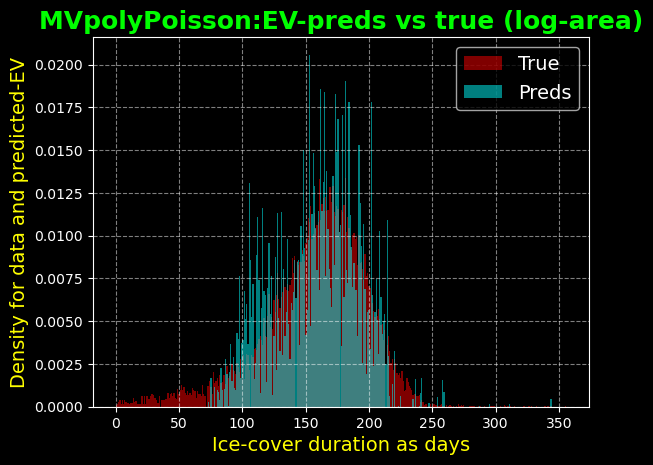

In [82]:
preds_vs_true_distribution(model_preds=mv_poly_poisson_model_preds,
                                true=pd.Series(y_mv.values.reshape(len(y_mv))),
                                titles={'title':'MVpolyPoisson:EV-preds vs true (log-area)',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Density for data and predicted-EV'},
                                colors={'title':'lime',
                                        'xlabel':'yellow',
                                        'ylabel':'yellow',
                                        'preds':'cyan',
                                        'true':'red'},
                                #file_path=visualization_path+'mv_poly_Poisson_EV_preds_vs_true_log_area.png',
                                #file_path=None
                                )

In [83]:
len(pd.Series(y_mv.values.reshape(len(y_mv)))),len(mv_poly_poisson_model_preds)

(22279, 22279)

In [84]:
mv_poly_poisson_model_preds.describe()

count    22279.000000
mean       158.488028
std         34.144955
min         73.360059
25%        132.914240
50%        162.189303
75%        183.732948
max        343.514589
dtype: float64

In [85]:
mvpolypoisson_model_distribution,mvpolypoisson_model_prob_matrix,mvpolypoisson_model_density = get_dataset_count_distribution(mv_poly_poisson_model,X_mv,return_probs=True)

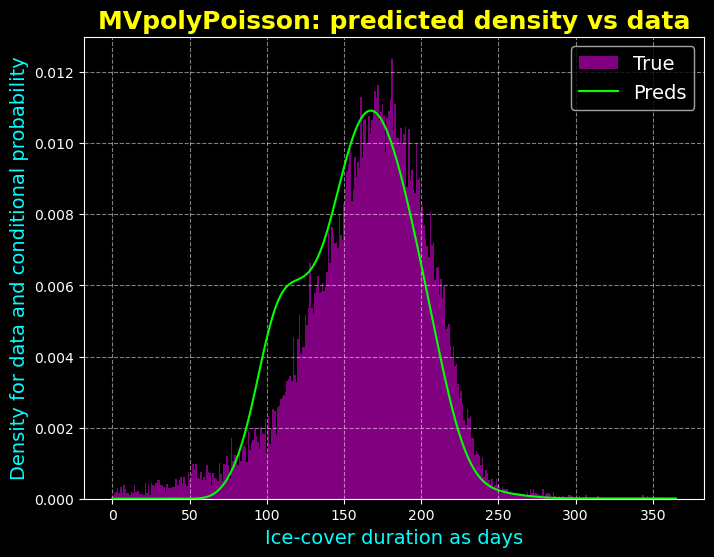

In [ ]:
colors_mvpolypoisson = {'preds':'lime','true':'purple','title':'yellow','xlabel':'cyan','ylabel':'cyan'}
titles_mvpolypoisson = {'title':'MVpolyPoisson: predicted density vs data','xlabel':'Ice-cover duration as days','ylabel':'Density for data and conditional probability'}

visualize_densities(prediction_density=mvpolypoisson_model_density,
                    true_observations=data_ip.ice_cover_duration,
                    colors=colors_mvpolypoisson,
                    titles=titles_mvpolypoisson,
                    #return_fig=True,
                    #file_path=visualization_path+'mv_poly_Poisson_duration_cumulated_density_vs_data_log_area.png'
                    )

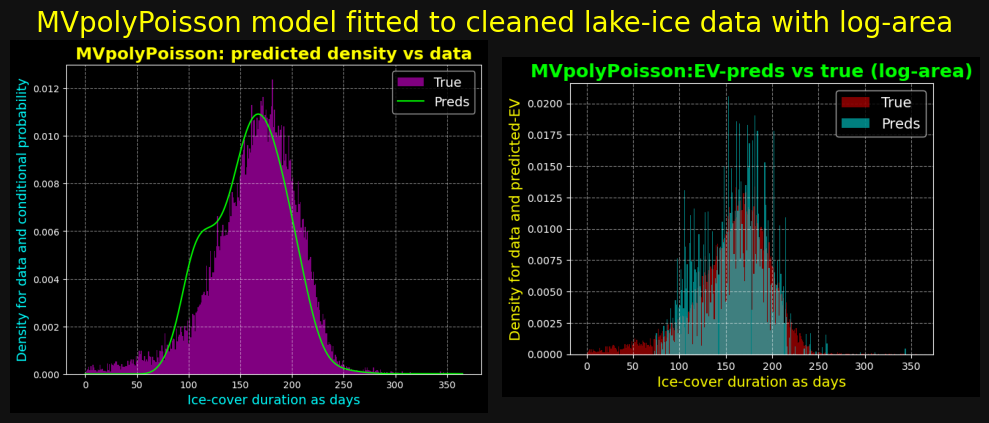

In [ ]:
density_path_mvpolypoisson = visualization_path+'mv_poly_Poisson_duration_cumulated_density_vs_data_log_area.png'
ev_path_mvpolypoisson = visualization_path+'mv_poly_Poisson_EV_preds_vs_true_log_area.png'

combine_plot_images(density_path=density_path_mvpolypoisson,
                    ev_path=ev_path_mvpolypoisson,
                    title='MVpolyPoisson model fitted to cleaned lake-ice data with log-area',
                    #file_path=visualization_path+'mv_poly_Poisson_combined_distribution_visualization.png',
                    )

## Short analysis with Famoyes model:
* Linear version works and produces legit statistical output with MinMax-scaled data.
* The EV-predictions of Famoyes model have high MSEs
* Standardized data for linear version, and Polynomial version for MinMax leads into trouble with matrix inversion.
* Shortly said, this model does not work for scaled multi-dimensional data. We could try to create tailor-made solution to fix the problems with matrix inversions.
* Basic Poisson-regression-type model can already capture the essential distribution, so makes no sense to continue further research with Generalized Poisson models in this case.
* Flexibility to variance assumptions of standard Poisson-regression can be achieved with tailor-made neural network solution.

In [90]:
import warnings
warnings.filterwarnings('ignore')

mv_lin_Poisson_eq = create_model_equation(df_ice_cover_duration.columns.values[:-1],df_ice_cover_duration.columns.values[-1][0])
y_mv,X_mv = dmatrices(mv_lin_Poisson_eq,
                            df_ice_cover_duration,
                            return_type="dataframe")

mv_lin_famoyes_model = sm.GeneralizedPoisson(y_mv,
                             X_mv,
                             p=2).fit(maxiter=10000)
mv_lin_famoyes_model_preds = mv_lin_famoyes_model.predict(X_mv)

print(mv_lin_famoyes_model.summary())

Optimization terminated successfully.
         Current function value: 5.022354
         Iterations: 19
         Function evaluations: 28
         Gradient evaluations: 28
                    GeneralizedPoisson Regression Results                     
Dep. Variable:     ice_cover_duration   No. Observations:                22279
Model:             GeneralizedPoisson   Df Residuals:                    22268
Method:                           MLE   Df Model:                           10
Date:                Sat, 05 Apr 2025   Pseudo R-squ.:                 0.06217
Time:                        21:34:41   Log-Likelihood:            -1.1189e+05
converged:                       True   LL-Null:                   -1.1931e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0388      0.001   

In [91]:
mean_squared_error(mv_lin_famoyes_model_preds,y_mv)

1108.605961090961

In [92]:
mv_lin_famoyes_mse_dict = short_mse_analysis(mv_lin_famoyes_model_preds,
                                              y_mv,
                                              return_variables=True)

MSE: 1108.605961090961
Squared error std scaled: 117.4454975334762
95% lower bound: 878.4127859253476
95% upper bound: 1338.7991362565745


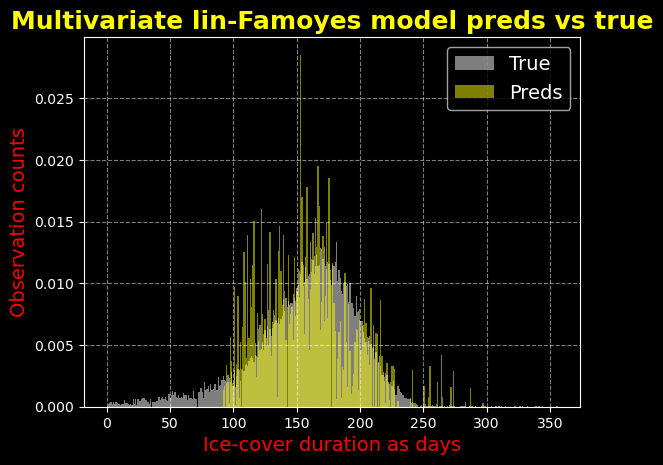

In [ ]:
preds_vs_true_distribution(model_preds=mv_lin_famoyes_model_preds,
                                true=pd.Series(y_mv.values.reshape(len(y_mv))),
                                titles={'title':'Multivariate lin-Famoyes model preds vs true',
                                        'xlabel':'Ice-cover duration as days',
                                        'ylabel':'Observation counts'},
                                colors={'title':'yellow',
                                        'xlabel':'red',
                                        'ylabel':'red',
                                        'preds':'yellow',
                                        'true':'white'},
                                #filename=visualization_path+'mv_lin_famoyes_duration_preds_vs_true.png',
                                #filename=None
                                )